# GHRSST VIIRS L2P SST - Gulf Stream (multi-granule)

Pulls ~20 VIIRS L2P swath granules over a single ocean basin via NASA Earthdata, concatenates the clear-sky pixels (>1M points after cloud masking), then fits an EFGP with hyper-parameter learning and benchmarks against SKI.

Requires: `pip install earthaccess xarray netCDF4`. The first run will prompt for your NASA Earthdata credentials.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.optim import Adam

sys.path.append('../../..')
from efgpnd import EFGPND
from kernels import SquaredExponential
from utils.ski import fit_ski_gp
from load_ghrsst import download_ghrsst, load_ghrsst_swath, load_ghrsst_torch

In [2]:
# Download up to 20 VIIRS L2P granules over the Gulf Stream for one day.
# Skips the network call if granules are already present in ./data.
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

BBOX = (-80.0, 25.0, -60.0, 45.0)  # lon_min, lat_min, lon_max, lat_max
TARGET_GRANULES = 20

existing = sorted(DATA_DIR.glob('*VIIRS*L2P*.nc')) + sorted(DATA_DIR.glob('*VIIRS*L2P*.nc4'))
if len(existing) >= TARGET_GRANULES:
    granule_paths = existing[:TARGET_GRANULES]
    print(f'Using {len(granule_paths)} cached granules')
else:
    granule_paths = download_ghrsst(
        short_name='VIIRS_NPP-STAR-L2P-v2.80',
        temporal=('2024-06-15', '2024-06-15'),
        bounding_box=BBOX,
        count=TARGET_GRANULES,
        out_dir=DATA_DIR,
    )
    print(f'Downloaded {len(granule_paths)} granules')

for p in granule_paths[:5]:
    print(f'  {p.name}')
if len(granule_paths) > 5:
    print(f'  ... ({len(granule_paths) - 5} more)')

/Users/colecitrenbaum/myenv/lib/python3.13/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/Users/colecitrenbaum/myenv/lib/python3.13/site-packages/earthaccess/store.py:832: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/5 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/5 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/5 [00:00<?, ?it/s]

Downloaded 5 granules
  20240615054000-STAR-L2P_GHRSST-SSTsubskin-VIIRS_NPP-ACSPO_V2.80-v02.0-fv01.0.nc
  20240615072000-STAR-L2P_GHRSST-SSTsubskin-VIIRS_NPP-ACSPO_V2.80-v02.0-fv01.0.nc
  20240615165000-STAR-L2P_GHRSST-SSTsubskin-VIIRS_NPP-ACSPO_V2.80-v02.0-fv01.0.nc
  20240615170000-STAR-L2P_GHRSST-SSTsubskin-VIIRS_NPP-ACSPO_V2.80-v02.0-fv01.0.nc
  20240615184000-STAR-L2P_GHRSST-SSTsubskin-VIIRS_NPP-ACSPO_V2.80-v02.0-fv01.0.nc


In [3]:
# Quick preview of the first granule (just to confirm structure / units).
lon_grid, lat_grid, sst_grid, sst_meta = load_ghrsst_swath(
    path=granule_paths[0],
    variable='sea_surface_temperature',
    quality_min=5,
    to_celsius=True,
    bbox=BBOX,
)
valid_sst = np.isfinite(sst_grid)
print(f"Granule time: {sst_meta['time']}")
print(f"Title: {sst_meta['title']}")
print(f"Swath shape: {sst_grid.shape}")
print(f"Valid SST pixels: {valid_sst.sum():,} / {valid_sst.size:,}")
print(f"SST range: {np.nanmin(sst_grid):.2f} to {np.nanmax(sst_grid):.2f} {sst_meta['units']}")

Granule time: 2024-06-15T05:40:01
Title: VIIRS L2P SST
Swath shape: (5392, 3200)
Valid SST pixels: 344,659 / 17,254,400
SST range: 8.43 to 29.33 Celsius


In [4]:
# fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
# sst_plot = np.ma.masked_invalid(sst_grid)
# pcm = ax.pcolormesh(lon_grid, lat_grid, sst_plot, cmap='coolwarm', shading='auto', rasterized=True)
# ax.set_title(f"VIIRS L2P SST (single swath) {sst_meta['time']}")
# ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
# ax.set_xlim(BBOX[0], BBOX[2]); ax.set_ylim(BBOX[1], BBOX[3])
# ax.grid(alpha=0.2)
# plt.colorbar(pcm, ax=ax, label=f"SST ({sst_meta['units']})")

In [5]:
# Concatenate clear-sky pixels across ALL granules.
x, y = load_ghrsst_torch(
    path=granule_paths,
    variable='sea_surface_temperature',
    quality_min=5,
    to_celsius=True,
    bbox=BBOX,
    n_sub=None,   # set e.g. 2_000_000 to cap
    seed=0,
)
print(f'x shape: {tuple(x.shape)}')
print(f'y shape: {tuple(y.shape)}')
print(f'Lon range: {x[:, 0].min():.3f} to {x[:, 0].max():.3f}')
print(f'Lat range: {x[:, 1].min():.3f} to {x[:, 1].max():.3f}')
print(f"SST range: {y.min():.2f} to {y.max():.2f} {sst_meta['units']}")

x shape: (2734033, 2)
y shape: (2734033,)
Lon range: -80.000 to -60.000
Lat range: 25.000 to 45.000
SST range: 6.42 to 32.34 Celsius


Text(0.5, 0.98, 'VIIRS L2P SST clear-sky pixels — 5 granules over Gulf Stream')

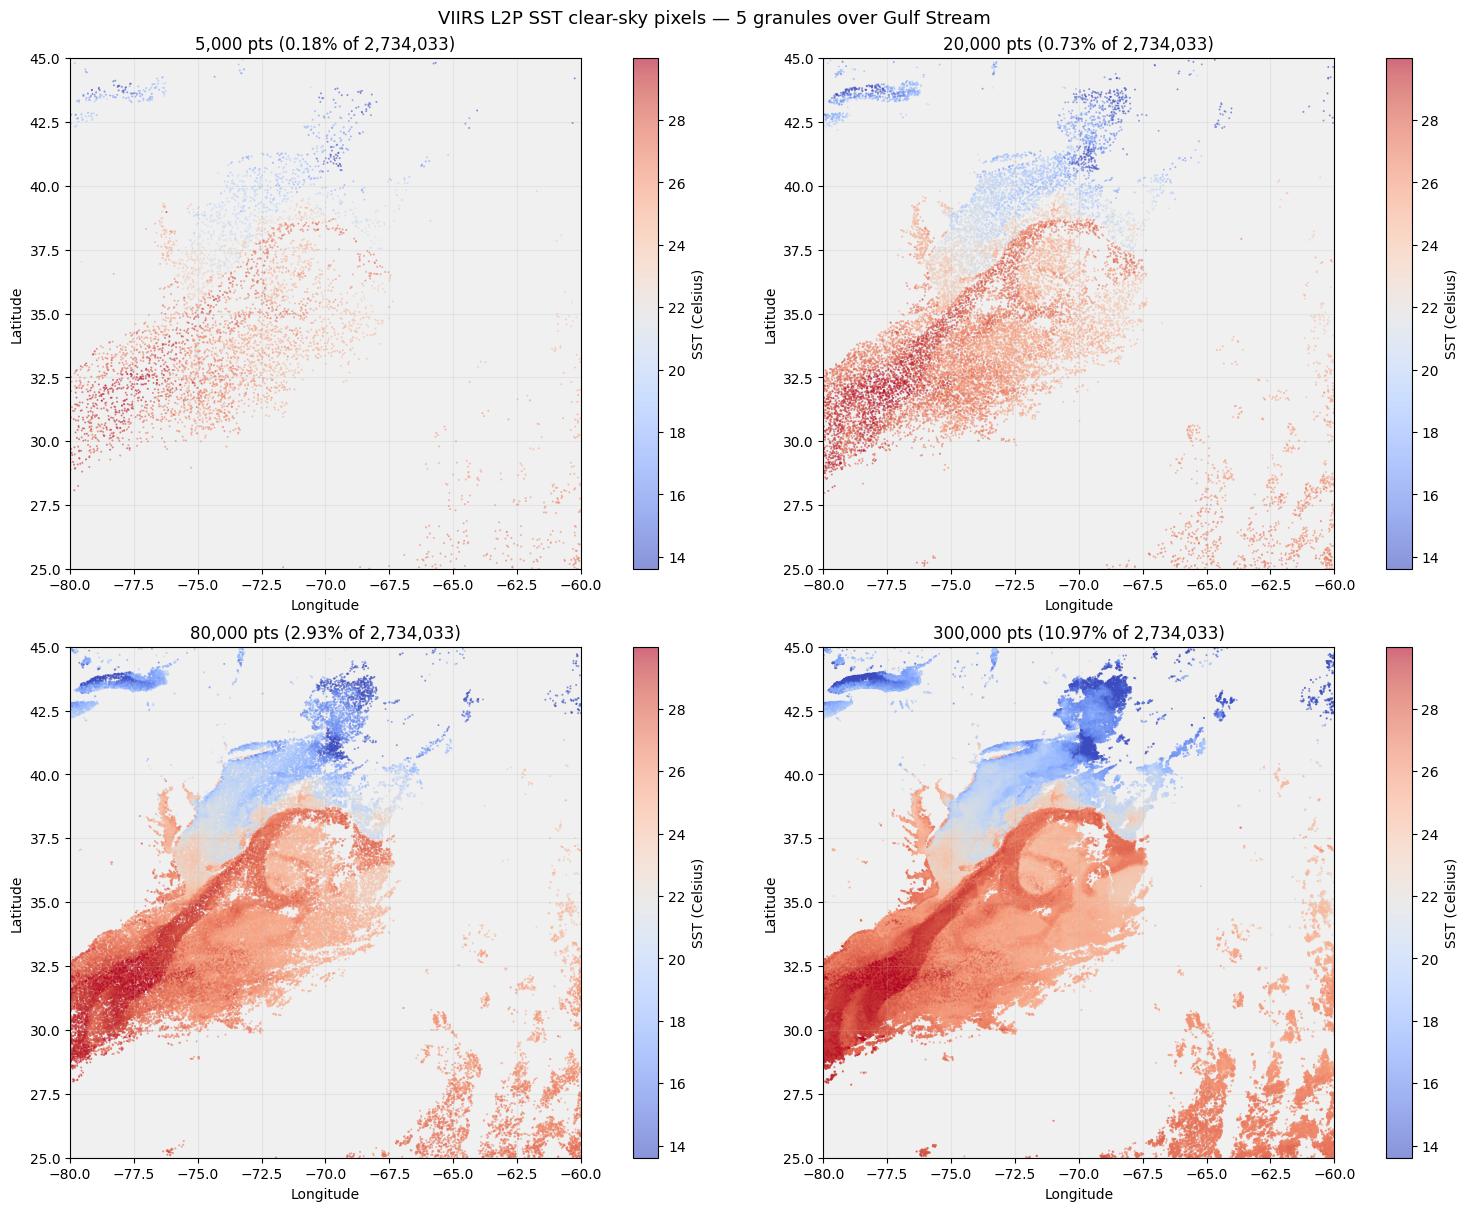

In [6]:
# Visualise the data at a few subsampling rates — too many points and you
# just see a coloured rectangle, too few and you miss the structure.
rng = np.random.default_rng(0)
sample_sizes = [5_000, 20_000, 80_000, 300_000]
vmin = float(np.nanpercentile(y.numpy(), 1))
vmax = float(np.nanpercentile(y.numpy(), 99))

fig, axes = plt.subplots(2, 2, figsize=(15, 12), constrained_layout=True)
for ax, n_plot in zip(axes.ravel(), sample_sizes):
    n = min(n_plot, len(y))
    idx = rng.choice(len(y), size=n, replace=False)
    ax.set_facecolor('#f0f0f0')
    sc = ax.scatter(
        x[idx, 0].numpy(), x[idx, 1].numpy(),
        c=y[idx].numpy(), s=2.0, cmap='coolwarm', alpha=0.6,
        vmin=vmin, vmax=vmax, linewidths=0, rasterized=True,
    )
    frac = n / len(y) * 100
    ax.set_title(f'{n:,} pts ({frac:.2f}% of {len(y):,})')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.set_xlim(BBOX[0], BBOX[2]); ax.set_ylim(BBOX[1], BBOX[3])
    ax.set_aspect('equal')
    ax.grid(alpha=0.2)
    fig.colorbar(sc, ax=ax, label=f"SST ({sst_meta['units']})")
fig.suptitle(f'VIIRS L2P SST clear-sky pixels — {len(granule_paths)} granules over Gulf Stream', fontsize=13)

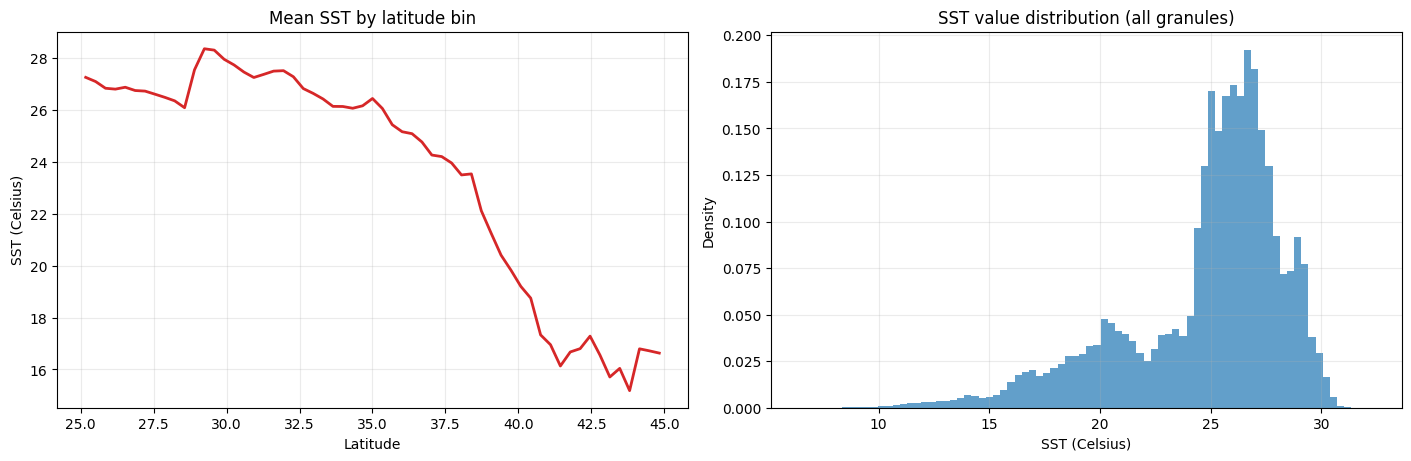

In [7]:
# Distribution + lat-binned mean from the merged point cloud.
y_np = y.numpy()
lat_np = x[:, 1].numpy()
lat_bins = np.linspace(BBOX[1], BBOX[3], 60)
lat_mid = 0.5 * (lat_bins[:-1] + lat_bins[1:])
lat_mean = np.array([
    y_np[(lat_np >= lo) & (lat_np < hi)].mean() if ((lat_np >= lo) & (lat_np < hi)).any() else np.nan
    for lo, hi in zip(lat_bins[:-1], lat_bins[1:])
])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
axes[0].plot(lat_mid, lat_mean, color='tab:red', linewidth=2)
axes[0].set_title('Mean SST by latitude bin')
axes[0].set_xlabel('Latitude'); axes[0].set_ylabel(f"SST ({sst_meta['units']})"); axes[0].grid(alpha=0.25)

axes[1].hist(y_np, bins=80, density=True, alpha=0.7, color='tab:blue')
axes[1].set_title('SST value distribution (all granules)')
axes[1].set_xlabel(f"SST ({sst_meta['units']})"); axes[1].set_ylabel('Density'); axes[1].grid(alpha=0.25)

In [8]:
# Normalize inputs to [0, 1] and standardize outputs (same convention as OISST notebook).
x_min, x_max = x.min(dim=0).values, x.max(dim=0).values
x = (x - x_min) / (x_max - x_min)

y_mean, y_std = y.mean(), y.std()
y = (y - y_mean) / y_std

print(f'x range per dim: {x.min(dim=0).values.tolist()} to {x.max(dim=0).values.tolist()}')
print(f'y mean={y.mean():.4f}, std={y.std():.4f}')

x = x.to(dtype=torch.float32)
y = y.to(dtype=torch.float32)

x range per dim: [0.0, 0.0] to [1.0, 1.0]
y mean=-0.0000, std=1.0000


In [9]:
d = x.shape[1]
EPSILON = 1e-3
cg_tol = 1e-4
noise_floor = 1e-4

init_ls = 0.1
init_var = 1.0
init_noise = 1.0

kernel_efgp = SquaredExponential(
    dimension=d, init_lengthscale=init_ls, init_variance=init_var
)
print(f'N = {x.shape[0]:,}, d = {d}')

N = 2,734,033, d = 2


In [12]:
max_iters = 50
J = 1

training_log = {
    'iter': [], 'lengthscale': [], 'variance': [], 'sigmasq': [],
    'mean_cg_iters': [], 'trace_cg_iters': [], 'mtot': [], 'feature_count': [],
}

model = EFGPND(x, y, kernel=kernel_efgp, sigmasq=init_noise, eps=EPSILON, estimate_params=False,opts={"mean_cg_preconditioner_type":"jacobi"})
optimizer = Adam(model.parameters(), lr=0.5)

training_log['iter'].append(0)
training_log['lengthscale'].append(model.kernel.get_hyper('lengthscale'))
training_log['variance'].append(model.kernel.get_hyper('variance'))
training_log['sigmasq'].append(model._gp_params.sig2.item())
for k in ('mean_cg_iters', 'trace_cg_iters', 'mtot', 'feature_count'):
    training_log[k].append(None)

for it in range(max_iters):
    optimizer.zero_grad()
    model.compute_gradients(trace_samples=J, cg_tol=cg_tol, noise_floor=noise_floor)
    optimizer.step()

    stats = model.last_gradient_stats
    mean_cg_iters = stats.get('mean_cg_iters')
    trace_cg_iters = stats.get('trace_cg_iters')
    mtot = stats.get('mtot')
    feature_count = stats.get('feature_count')

    lengthscale = model.kernel.get_hyper('lengthscale')
    variance = model.kernel.get_hyper('variance')
    sigmasq = model._gp_params.sig2.item()
    training_log['iter'].append(it + 1)
    training_log['lengthscale'].append(lengthscale)
    training_log['variance'].append(variance)
    training_log['sigmasq'].append(sigmasq)
    training_log['mean_cg_iters'].append(mean_cg_iters)
    training_log['trace_cg_iters'].append(trace_cg_iters)
    training_log['mtot'].append(mtot)
    training_log['feature_count'].append(feature_count)

    if it % 10 == 0:
        print(
            f"iter {it+1:>3}  \u2113={lengthscale:.4g}  \u03c3_f\u00b2={variance:.4g}  \u03c3_n\u00b2={sigmasq:.4g}  "
            f"cg(mean/trace)={mean_cg_iters}/{trace_cg_iters}  mtot={mtot}  M={feature_count}"
        )

print(
    f"Final: \u2113={lengthscale:.4g}, \u03c3_f\u00b2={variance:.4g}, \u03c3_n\u00b2={sigmasq:.4g}, "
    f"cg(mean/trace)={mean_cg_iters}/{trace_cg_iters}, mtot={mtot}, M={feature_count}"
)

iter   1  ℓ=0.06184  σ_f²=1.344  σ_n²=0.714  cg(mean/trace)=303/195  mtot=21  M=441
iter  11  ℓ=0.003922  σ_f²=2.541  σ_n²=0.009129  cg(mean/trace)=239/160  mtot=383  M=146689


KeyboardInterrupt: 

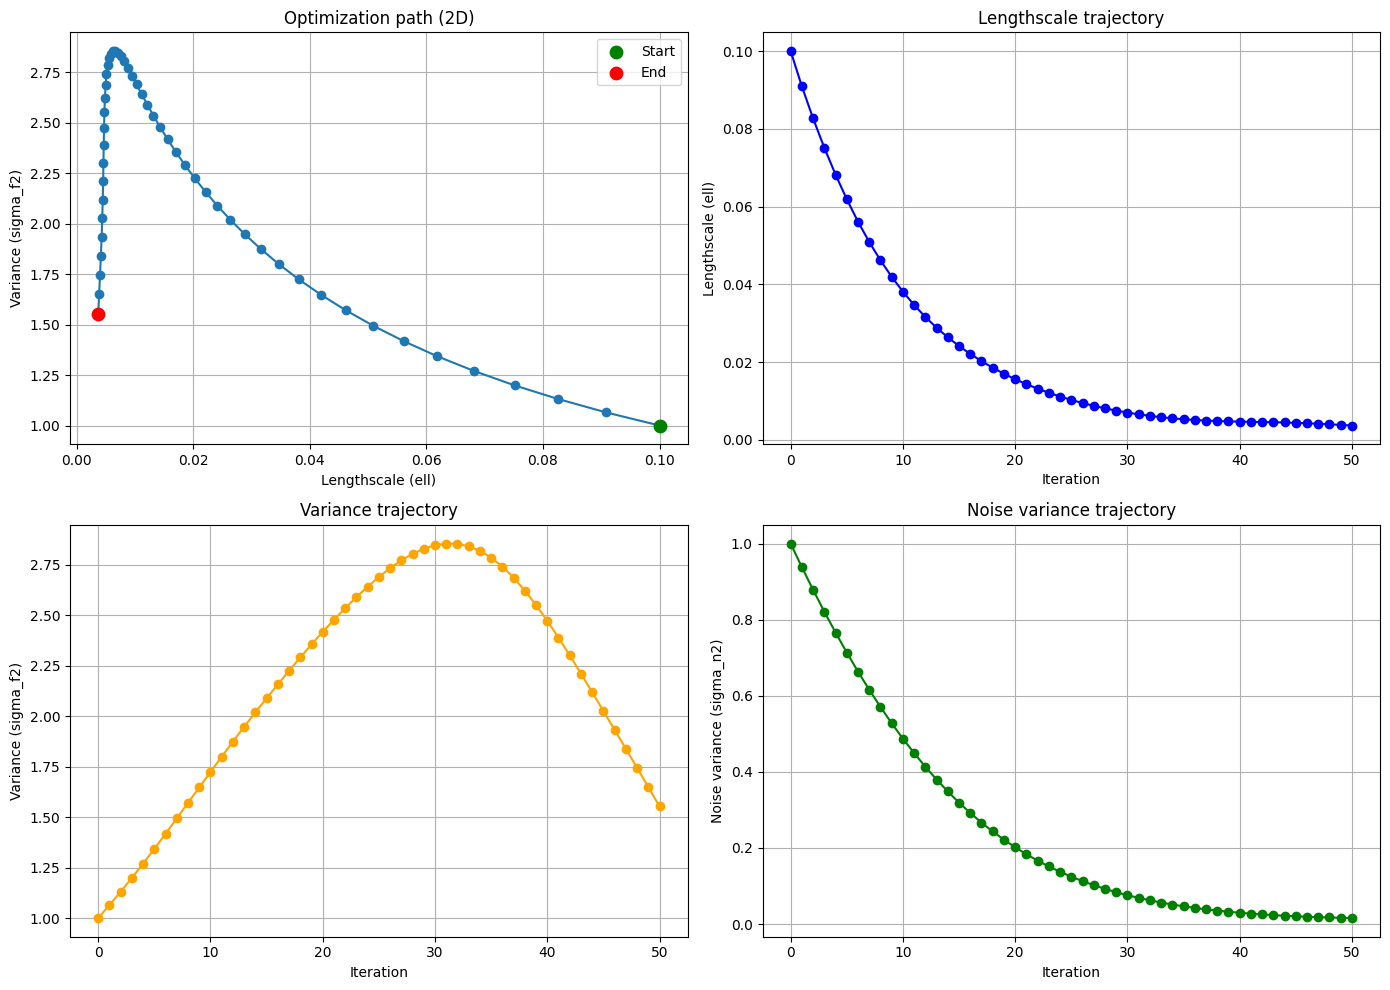

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
ax1.plot(training_log['lengthscale'], training_log['variance'], 'o-')
ax1.scatter(training_log['lengthscale'][0], training_log['variance'][0], color='green', s=80, label='Start', zorder=5)
ax1.scatter(training_log['lengthscale'][-1], training_log['variance'][-1], color='red', s=80, label='End', zorder=5)
ax1.set_xlabel('Lengthscale (ell)'); ax1.set_ylabel('Variance (sigma_f2)')
ax1.set_title('Optimization path (2D)'); ax1.legend(); ax1.grid(True)

axes[0, 1].plot(training_log['iter'], training_log['lengthscale'], 'o-', color='blue')
axes[0, 1].set_xlabel('Iteration'); axes[0, 1].set_ylabel('Lengthscale (ell)')
axes[0, 1].set_title('Lengthscale trajectory'); axes[0, 1].grid(True)

axes[1, 0].plot(training_log['iter'], training_log['variance'], 'o-', color='orange')
axes[1, 0].set_xlabel('Iteration'); axes[1, 0].set_ylabel('Variance (sigma_f2)')
axes[1, 0].set_title('Variance trajectory'); axes[1, 0].grid(True)

axes[1, 1].plot(training_log['iter'], training_log['sigmasq'], 'o-', color='green')
axes[1, 1].set_xlabel('Iteration'); axes[1, 1].set_ylabel('Noise variance (sigma_n2)')
axes[1, 1].set_title('Noise variance trajectory'); axes[1, 1].grid(True)
plt.tight_layout()